In [ ]:
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob
import numpy as np
import yaml
import monai.networks.nets
from tqdm import tqdm
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureType,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityd,
    ScaleIntensityRanged,
    NormalizeIntensity,
    Spacingd,
    Invert,
    Invertd,
    ResizeD,
    Resize,
    LoadImage,
    Rotate,
    Randomizable,
    Transform,
    EnsureType,
)
from monai.handlers.utils import from_engine
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, ThreadDataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
from aim.pytorch import track_gradients_dists, track_params_dists
from matplotlib.widgets import Button, Slider

cpu


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.52it/s]


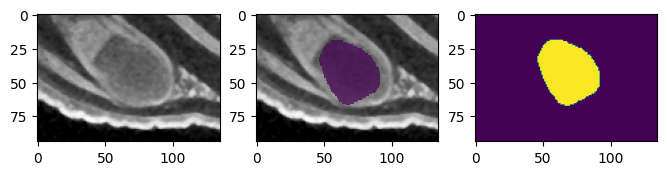

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.66it/s]


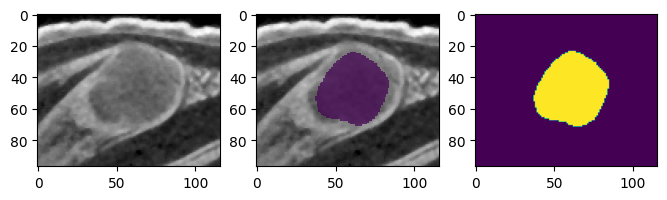

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.73it/s]


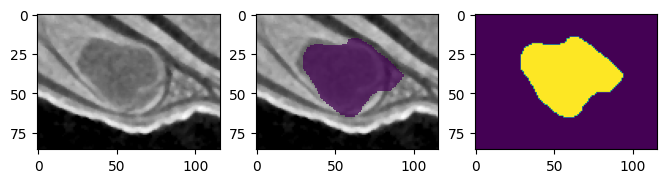

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  2.52it/s]


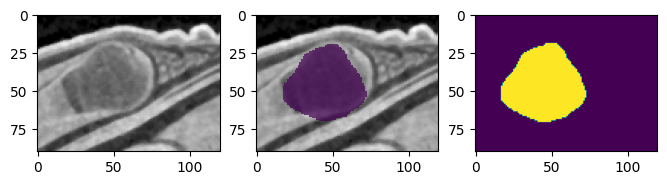

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.68it/s]


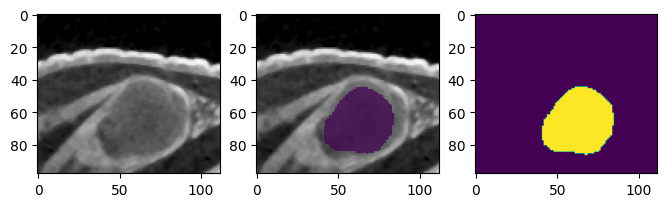

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.67it/s]


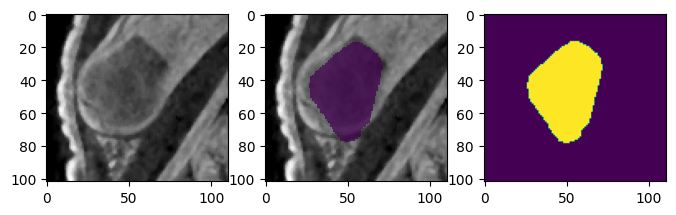

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.38it/s]


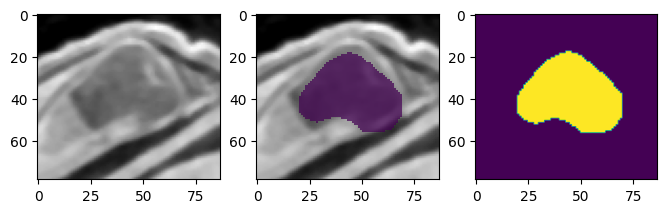

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.72it/s]


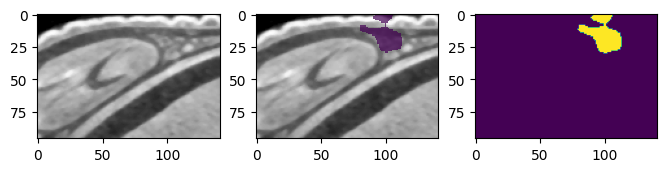

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [01:00<00:00,  7.62s/it]


In [56]:
### USER INPUT REQUIRED ###
# Root path to where the data is located
DATA_DIR = "/Users/adnanzai/Downloads/monai-train/sample"
MODEL_NAME = "/Users/adnanzai/Downloads/monai-train/inferencer/best_metric_model.pth" # Full path to model pickle file, including name. ex: /home/usr/model.pth
MODEL_CONFIG_FILE = "/Users/adnanzai/Downloads/monai-train/example/model_unet.yaml" # Full path to model configuration file, This could be the example/model_*.yaml or example/optuna_config.yaml
_SEED=31890
###

set_determinism(seed=_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
with open(MODEL_CONFIG_FILE, 'r') as stream:
    config = yaml.safe_load(stream)

model_type = config['model']['type']
model = getattr(monai.networks.nets, model_type)(**config['model']['architecture'])

# Load model weights with CPU/GPU compatibility
model.load_state_dict(torch.load(MODEL_NAME, map_location=device))
model.to(device)
model.eval()  # Set the model to evaluation mode


# Automatically locates the 'imagesTs' folder
test_images = sorted(glob.glob(os.path.join(DATA_DIR, "imagesTs", "*.nii.gz")))
test_data = [{"image": image} for image in test_images]

test_org_transforms = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        ResizeD(keys="image", spatial_size=config['model']['image_size']),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(2.5, 2.5, 1.0), mode="bilinear"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image"], source_key="image"),
    ]
)
"""
test_org_transforms = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        ResizeD(keys="image", spatial_size=config['model']['image_size']),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.0, 2.0, 2.0), mode="bilinear"),
        CropForegroundd(keys=["image"], source_key="image"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        #ScaleIntensityd(keys=["image"], minv=0, maxv=256),
        EnsureType()
    ]
)
post_transforms = Compose(
    [
        EnsureType(),
        Invertd(
            keys="pred",
            transform=test_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=True,
            to_tensor=True,
        ),
        SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
    ]
)
"""
post_transforms = Compose(
    [
        EnsureType(),
        Invertd(
            keys="pred",
            transform=test_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
        ),
        AsDiscreted(keys="pred", argmax=True, to_onehot=2),
        #SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
    ]
)

# Loads data into the data loader
test_org_ds = Dataset(data=test_data, transform=test_org_transforms)
test_org_loader = ThreadDataLoader(test_org_ds, batch_size=1, num_workers=4)
loader = LoadImage()

with torch.no_grad():
    for test_data in tqdm(test_org_loader):
        test_inputs = test_data["image"].to(device)
        roi_size = 68 # Adjustable parameter to present overall image dimensions
        sw_batch_size = 4
        slice = 40 # Adjustable parameter (slice to visualize in the plots). Note inference is performed on the entire 3D dataset.
        '''
        test_data["pred"] = sliding_window_inference(inputs=test_inputs, predictor=model, 
                                                    roi_size=roi_size, sw_batch_size=sw_batch_size,
                                                    overlap=0.5, 
                                                    sigma_scale=0.5,
                                                    padding_mode="circular")
        '''
        # Define the number of times to run the inference
        num_runs = 10

        # Initialize a list to store the results
        accumulated_pred = None


        for i in tqdm(range(num_runs)):
            # Set a different seed for each run
            seed = i + _SEED  # Choose a base seed and increment for each run
            set_determinism(seed=seed)
            np.random.seed(seed)
            # Run the inference
            pred = sliding_window_inference(
                inputs=test_inputs,
                predictor=model,
                roi_size=roi_size,
                sw_batch_size=sw_batch_size,
                overlap=0.1,
                sigma_scale=0.2,
                padding_mode="circular"
            )
            # Accumulate the predictions (sum them)
            
            if accumulated_pred is None:
                accumulated_pred = pred
            else:
                accumulated_pred += pred

        # After accumulating all the predictions, take the average
        averaged_pred = accumulated_pred / num_runs

        # Assign the averaged prediction back to test_data["pred"]
        test_data["pred"] = averaged_pred
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]

        test_output = from_engine(["pred"])(test_data)

        original_image = loader(test_output[0].meta["filename_or_obj"])

        plt.figure("check", (8,8))
        plt.subplot(1,3,1)
        plt.imshow(original_image[:, :, slice], cmap="gray")

        mask_pred = np.zeros(original_image[:, :, slice].shape)
        mask_pred[test_output[0].detach().cpu().numpy()[1, :, :, slice]==1] = 1
        masked_pred = np.ma.masked_where(mask_pred == 0, mask_pred)
        plt.subplot(1, 3, 2)
        plt.imshow(original_image[:, :, slice], cmap="gray")
        plt.imshow(masked_pred, alpha=0.7)

        plt.subplot(1,3,3)
        plt.imshow(test_output[0].detach().cpu().numpy()[1, :, :, slice])

        plt.show()